## Consolidación final del proyecto

Este notebook une los resultados de las 4 fases (rendimiento/gasto/entrenador, cantera, valor de plantilla, presidentes) en un solo dataset, y resume los hallazgos principales de todo el proyecto en conjunto, como paso previo a construir el dashboard en Tableau Public.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats

In [2]:
df_maestro = pd.read_csv('../data/processed/df_maestro.csv', dtype={'temporada': str})
uso_cantera = pd.read_csv('../data/processed/uso_cantera_temporada.csv', dtype={'temporada': str})
valor_plantilla = pd.read_csv('../data/processed/valor_plantilla_temporada.csv', dtype={'temporada': str})

dataset_final = df_maestro.merge(
    uso_cantera[['temporada', 'porcentaje_cantera']], on='temporada', how='left'
).merge(
    valor_plantilla[['temporada', 'valor_plantilla', 'valor_relativo_plantilla']], on='temporada', how='left'
)

dataset_final.to_csv('../data/processed/dataset_final.csv', index=False)
print(dataset_final.shape)
dataset_final.head()

(33, 28)


,temporada,posicion,puntos,partidos_jugados,victorias,empates,derrotas,goles_favor,goles_contra,diferencia_gol,...,proporcion_mercado_barca,puntos_por_victoria,puntos_maximos_posibles,rendimiento_relativo,categoria_temporada,presidente_principal,hubo_cambio_presidente,porcentaje_cantera,valor_plantilla,valor_relativo_plantilla
0,9394,1,56,38,25,6,7,91,42,49,...,0.184726,2,76,0.736842,Título,Josep Lluís Núñez,False,NaN,NaN,NaN
1,9495,4,46,38,18,10,10,60,45,15,...,-0.048207,2,76,0.605263,Top 4,Josep Lluís Núñez,False,NaN,NaN,NaN
2,9596,3,80,42,22,14,6,72,39,33,...,-0.002450,3,126,0.634921,Top 4,Josep Lluís Núñez,False,NaN,NaN,NaN
3,9697,2,90,42,28,6,8,102,48,54,...,0.126075,3,126,0.714286,Top 4,Josep Lluís Núñez,False,NaN,NaN,NaN
4,9798,1,74,38,23,5,10,78,56,22,...,0.075187,3,114,0.649123,Título,Josep Lluís Núñez,False,NaN,NaN,NaN


### Comparando las 5 variables en la misma unidad

Gasto, cantera y valor de plantilla son variables numéricas continuas, así que Pearson (r) las compara directamente. Entrenador y presidente son categóricos (nombres, no números), así que se necesita una técnica distinta: ANOVA, que produce un valor llamado eta cuadrado (η²), interpretable igual que un R² (0 a 1, "proporción de varianza explicada"). Para comparar las 5 variables en la misma escala, se usa r² (no r) para las continuas, y η² para las categóricas.

**Ajuste necesario para que η² no salga inflado artificialmente:** cuando un grupo tiene una sola observación (un entrenador con 1 sola temporada), la varianza dentro de ese grupo es matemáticamente cero, lo que hace que toda su diferencia respecto al promedio general se cuente como "explicada por la categoría", sin que eso refleje un patrón real. Por eso, únicamente para este cálculo puntual, se filtran los entrenadores con menos de 2 temporadas (mismo criterio de muestra mínima ya usado en el resto del proyecto). Este filtro aplica solo aquí, no cambia ninguna tabla ni gráfico anterior del proyecto, donde los casos de 1 temporada siguen presentes con su nota correspondiente.

In [3]:
def eta_cuadrado(df, variable_categorica, variable_continua):
    grupos = [grupo[variable_continua].values for _, grupo in df.groupby(variable_categorica)]
    f_stat, p_valor = stats.f_oneway(*grupos)

    gran_media = df[variable_continua].mean()
    ss_total = ((df[variable_continua] - gran_media) ** 2).sum()
    ss_entre = sum(len(g) * (g.mean() - gran_media) ** 2 for g in grupos)
    eta2 = ss_entre / ss_total
    return eta2, p_valor

In [4]:
entrenadores_2plus = dataset_final['entrenador_principal'].value_counts()
entrenadores_2plus = entrenadores_2plus[entrenadores_2plus >= 2].index
datos_entrenador_filtrado = dataset_final[dataset_final['entrenador_principal'].isin(entrenadores_2plus)]

eta2_entrenador, p_entrenador = eta_cuadrado(datos_entrenador_filtrado, 'entrenador_principal', 'rendimiento_relativo')
eta2_presidente, p_presidente = eta_cuadrado(dataset_final.dropna(subset=['presidente_principal']), 'presidente_principal', 'rendimiento_relativo')

print(f'Entrenador (2+ temporadas, {len(entrenadores_2plus)} entrenadores): eta²={eta2_entrenador:.3f}, p={p_entrenador:.3f}')
print(f'Presidente (5, todos con 2+ temporadas): eta²={eta2_presidente:.3f}, p={p_presidente:.3f}')

Entrenador (2+ temporadas, 9 entrenadores): eta²=0.727, p=0.000
Presidente (5, todos con 2+ temporadas): eta²=0.606, p=0.000


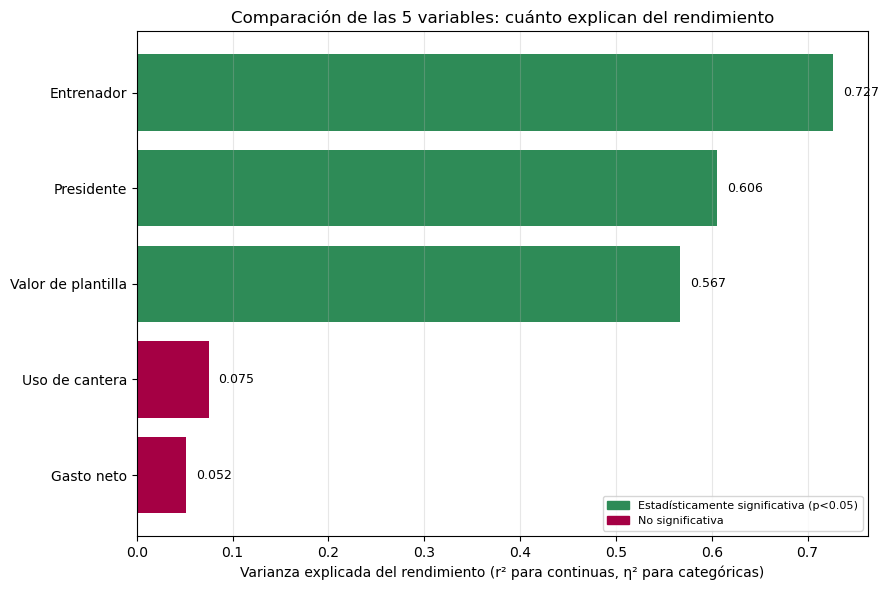

In [5]:
comparacion = pd.DataFrame({
    'variable': ['Gasto neto', 'Uso de cantera', 'Valor de plantilla', 'Presidente', 'Entrenador'],
    'varianza_explicada': [0.227**2, 0.274**2, 0.753**2, eta2_presidente, eta2_entrenador],
    'significativa': [False, False, True, True, True]
})
comparacion = comparacion.sort_values('varianza_explicada')

fig, ax = plt.subplots(figsize=(9, 6))
colores = comparacion['significativa'].map({True: '#2e8b57', False: '#a50044'})
ax.barh(comparacion['variable'], comparacion['varianza_explicada'], color=colores)

for i, valor in enumerate(comparacion['varianza_explicada']):
    ax.text(valor + 0.01, i, f'{valor:.3f}', va='center', fontsize=9)

ax.set_xlabel('Varianza explicada del rendimiento (r² para continuas, η² para categóricas)')
ax.set_title('Comparación de las 5 variables: cuánto explican del rendimiento')

from matplotlib.patches import Patch
leyenda = [Patch(color='#2e8b57', label='Estadísticamente significativa (p<0.05)'),
           Patch(color='#a50044', label='No significativa')]
ax.legend(handles=leyenda, loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig('../reports/figures/resumen_correlaciones_completo.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# export para Tableau: mismo contenido que 'comparacion', pero con 'significativa' como texto
# (Si/No en vez de True/False) y una columna que aclara que tipo de metrica es cada fila,
# porque r2 y eta2 vienen de pruebas distintas (Pearson vs ANOVA) aunque compartan escala
comparacion_export = comparacion.copy()
comparacion_export['significativa'] = comparacion_export['significativa'].map({True: 'Si', False: 'No'})
comparacion_export['tipo_metrica'] = ['eta cuadrado' if v in ('Presidente', 'Entrenador') else 'r cuadrado'
                                       for v in comparacion_export['variable']]
comparacion_export = comparacion_export.sort_values('varianza_explicada', ascending=False)

comparacion_export.to_csv('../data/processed/comparacion_final_variables.csv', index=False)
comparacion_export

,variable,varianza_explicada,significativa,tipo_metrica
4,Entrenador,0.726740,Si,eta cuadrado
3,Presidente,0.605942,Si,eta cuadrado
2,Valor de plantilla,0.567009,Si,r cuadrado
1,Uso de cantera,0.075076,No,r cuadrado
0,Gasto neto,0.051529,No,r cuadrado


In [7]:
print('Cantera - std:', uso_cantera['porcentaje_cantera'].std(), '| rango:', uso_cantera['porcentaje_cantera'].max() - uso_cantera['porcentaje_cantera'].min())
print('Valor plantilla - std:', valor_plantilla['valor_relativo_plantilla'].std(), '| rango:', valor_plantilla['valor_relativo_plantilla'].max() - valor_plantilla['valor_relativo_plantilla'].min())

cv_cantera = uso_cantera['porcentaje_cantera'].std() / uso_cantera['porcentaje_cantera'].mean()
cv_valor = valor_plantilla['valor_relativo_plantilla'].std() / valor_plantilla['valor_relativo_plantilla'].mean()
print('Coeficiente de variación cantera:', cv_cantera)
print('Coeficiente de variación valor plantilla:', cv_valor)

Cantera - std: 0.07105654067698053 | rango: 0.2759692550764682
Valor plantilla - std: 0.022410308331457178 | rango: 0.08688715337582369
Coeficiente de variación cantera: 0.16230914151350662
Coeficiente de variación valor plantilla: 0.1318784458670894


## Resumen consolidado: los 5 hallazgos centrales del proyecto

A lo largo de las 4 fases, se probó la misma pregunta de fondo (¿qué explica el rendimiento del Barça?) contra cinco variables: gasto en fichajes, uso de cantera, valor de mercado de la plantilla, entrenador, y presidente. Comparando todas en la misma unidad (varianza explicada del rendimiento: r² para las continuas, η² para las categóricas), el resultado es contundente:

| Variable | Varianza explicada | Significativa (p<0.05) |
|---|---|---|
| Gasto neto (% del mercado) | 0.052 | No |
| Uso de cantera (% de minutos) | 0.075 | No |
| Valor de plantilla (% del mercado) | 0.567 | Sí |
| Presidente | 0.606 | Sí |
| Entrenador | 0.727 | Sí |

**El entrenador es la variable que más explica el rendimiento de todo el proyecto**, por encima incluso del valor acumulado de la plantilla, que ya era el hallazgo más fuerte encontrado hasta la Fase 3. El presidente queda muy cerca en segundo lugar. Gasto y cantera, las dos variables de "cuánto se invierte", quedan muy por debajo de las tres restantes, todas relacionadas con "quién decide" o "qué talento ya se tiene acumulado".

**Precaución estadística necesaria:** η² tiende a crecer con el número de grupos, así que estos valores no son directamente comparables como si vinieran de exactamente el mismo tipo de prueba que r². Además, para el cálculo de entrenador se excluyeron los que tuvieron una sola temporada (mismo criterio de muestra mínima ya usado en el resto del proyecto), porque un grupo de tamaño 1 infla artificialmente η² al no tener varianza interna que restar.

**Conclusión final:** ni el gasto ni el uso de cantera predicen bien el rendimiento del Barça en 33 años de historia. El valor acumulado de la plantilla sí, y quién está al mando (entrenador, y en segundo lugar presidente) explica aún más. Esto es consistente con la hipótesis planteada como reflexión desde el cierre de Fase 2: la calidad de las decisiones de quienes están al mando parece pesar más que la disponibilidad de recursos, dado que el Barça cuenta de forma prácticamente constante con cantera de calidad y capacidad de fichaje. Confirmar esto con rigor causal (no solo descriptivo) requeriría datos comparables de otros clubes, fuera del alcance de este proyecto.

**Nota sobre una hipótesis descartada:** se consideró si la correlación débil de cantera (a diferencia de valor de plantilla) podía deberse simplemente a que el porcentaje de uso de cantera varía poco entre temporadas (poca "señal" para detectar). Se comprobó con el coeficiente de variación de ambas variables: cantera (0.162) y valor de plantilla (0.132) tienen variabilidad relativa similar, cantera incluso ligeramente mayor. Si la falta de variación explicara la correlación débil, valor de plantilla (con menos variación relativa) debería correlacionar peor, y ocurre lo contrario. Se descarta esta hipótesis: la diferencia entre ambas variables no se debe a cuánto varían, sino a que probablemente el rendimiento depende más de la calidad específica de los jugadores de cantera que juegan (algo que valor de plantilla sí captura indirectamente, al reflejar el valor de mercado individual) que de simplemente cuántos minutos acumulan en total.

**Con esto se cierra el análisis completo del proyecto.** Sigue el dashboard final en Tableau Public.

